In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com//selva86//datasets//master//BostonHousing.csv"
data = pd.read_csv(url)

X = data.drop("medv", axis=1)
y = data["medv"]

print(X.head())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [3]:
# checking for number of rows and columns
print(X.shape)

(506, 13)


In [16]:
# Add target column to feature set
X['price'] = y

In [5]:
print(X.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  price  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


In [6]:
print(X.shape)

(506, 14)


In [7]:
X.isnull().sum()  # checkin missing values


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
price      0
dtype: int64

In [21]:
# statistical measures about the data
print(X.describe())

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

In [8]:
# understanding correlation between various features in the dataset
# positive corre;\lation(one feature increases, other feature also increases)
# negative correlation(one feature increases, other feature decreases)
correlation = X.corr()


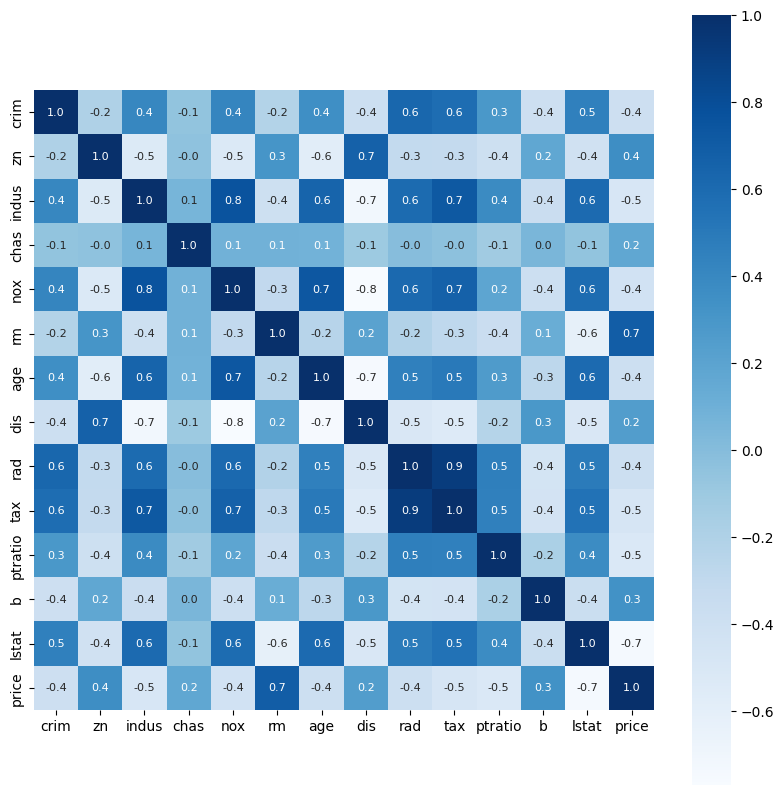

In [9]:
# understanding  heatmap
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
# 
plt.show()

In [18]:
# print(data.columns)
print(X.head())
# print(y.head())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  price  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


In [19]:
print(data.columns.tolist())


['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


In [20]:
X = data.drop("medv", axis=1)
y = data["medv"]


In [21]:
X.head()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [22]:
X['price'] = y

In [23]:
X.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [29]:
print(data.columns.tolist())


['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


In [ ]:
# split data and target (our target is medv(price) column)
X = data.drop("medv", axis=1)
y = data["medv"]


In [32]:
print(X.head())
print(y.head())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64


In [33]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=2)

In [34]:
print(X.shape, X_train.shape, X_test.shape)

(506, 13) (102, 13) (404, 13)


In [35]:
#Model Training  : XGBoost Regressor
# loading the model
model = XGBRegressor()


In [36]:
# Train the model with X_train
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
# Evaluation
# prediction on test data
# accuracy for predeictions on training data
y_pred = model.predict(X_train)

In [38]:
print(y_pred)

[20.200249  15.299977  37.30079   32.499466   8.800669  14.4001
 21.999708  26.599693  14.999938  21.499052  29.399431  24.799274
 21.997671  16.101519  13.899689  21.600683  21.699461  12.799689
  7.2003956 12.60087   20.69952   19.302011  36.499134  17.700764
 16.699896  20.199297  49.99981   34.599335  35.39973   19.40015
 20.800615  21.099665  31.099064  23.499866   8.299227  15.600799
 11.300267  21.699669  23.201015  20.800114  22.000153  13.600901
 28.700989  10.499858  23.000042  13.802943  36.399296  18.398563
 30.100412  17.898666  29.899721  30.700144   5.0013523 35.399235
 27.89871   18.400114  18.500546  17.49991   15.599712  22.399836
 20.30027   20.600023  19.798643  28.200459  35.100426  27.497509
 48.499367  27.499222  11.499715  22.000221  13.200416   7.399982
 20.600233  20.099237  25.102955  22.000164  19.099922  24.297012
 19.400135  23.898577  34.90065   19.39923   21.400387  26.600395
 37.59948   36.00056   21.399343  23.60043   24.80172   19.899824
 20.901844  1

In [ ]:
# R squared error
r2_square = metrics.r2_score(y_train, y_pred)
print("R squared error : ", r2_square)

#mean absolute error
mae = metrics.mean_absolute_error(y_train, y_pred)
print("Mean Absolute Error : ", mae)
# model performing good as r2_score is close to 1

R squared error :  0.9999999897764287
Mean Absolute Error :  0.0006610674016614862


In [40]:
# predicting price for test data
y_test_pred = model.predict(X_test)

In [41]:
# R squared error for test data
r2_square = metrics.r2_score(y_test, y_test_pred)
print("R squared error : ", r2_square)

#mean absolute error
mae = metrics.mean_absolute_error(y_test, y_test_pred)
print("Mean Absolute Error : ", mae)
# model performing good as r2_score is close to 1

R squared error :  0.7696005725307001
Mean Absolute Error :  2.7888650105731325


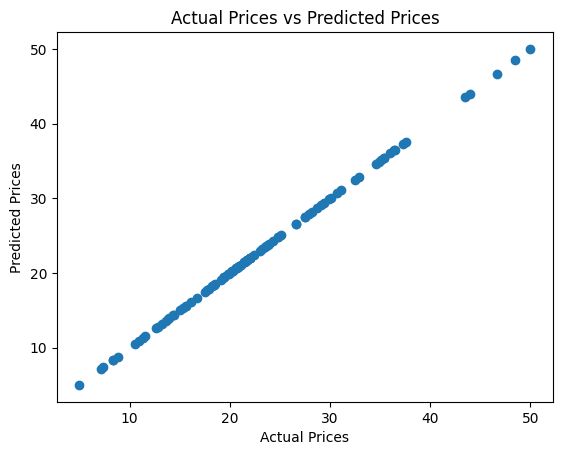

In [42]:
# Visualize the actual prices and predicted prices
plt.scatter(y_train, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()